# Projeto de ciência de dados: conjunto Pima Indians Diabetes

**Francisco Aparecido Rodrigues**  
Universidade de São Paulo, São Carlos, Brasil  
<https://sites.icmc.usp.br/francisco>  

<hr>

Este notebook é uma revisão prática dos seguintes tópicos:

1. carregar uma base de dados em um `DataFrame`;
2. explorar a estrutura dos dados;
3. identificar e tratar valores ausentes;
4. calcular estatísticas descritivas;
5. visualizar distribuições dos atributos;
6. analisar relações entre variáveis;
7. preparar os dados para aprendizado de máquina;
8. treinar um classificador Knn (k-vizinhos mais próximos);
10. avaliar o modelo utilizando métricas de classificação.

Vamos trabalhar com o **Pima Indians Diabetes Dataset**, um conjunto clássico da literatura de aprendizado de máquina: 768 pacientes do sexo feminino, de ascendência Pima (um povo indígena do sudoeste dos EUA), com 8 atributos clínicos, e o alvo indicando se a paciente desenvolveu diabetes dentro de 5 anos após a coleta dos dados. É uma base pequena o suficiente para explorarmos com calma, mas com problemas reais de qualidade de dados.

https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

### 1. Carregando os dados em um DataFrame

Inicialmente, vamos ler os dados de um arquivo.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Lê os dados do Google Drive
#from google.colab import drive
# Monta o Google Drive na pasta '/content/drive' deste ambiente do Colab.
# Depois deste comando, os arquivos do seu Drive ficam acessíveis normalmente,
# como se fossem arquivos locais dentro de '/content/drive/MyDrive/...'
#drive.mount('/content/drive/')
#caminho_drive = '/content/drive/MyDrive/data/diabetes.csv'
caminho = 'https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv'
dados = pd.read_csv(caminho, header=0)

# Descomente para ler do computador (offline)
#dados = pd.read_csv("data/diabetes.csv")

print(dados.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Um pequeno glossário das colunas, para referência ao longo do notebook:

| Coluna | Significado |
|---|---|
| `Pregnancies` | Número de gestações |
| `Glucose` | Concentração de glicose plasmática (teste oral de tolerância à glicose) |
| `BloodPressure` | Pressão arterial diastólica (mm Hg) |
| `SkinThickness` | Espessura da dobra cutânea do tríceps (mm) |
| `Insulin` | Insulina sérica após 2 horas (mu U/ml) |
| `BMI` | Índice de massa corporal (peso em kg / altura em m²) |
| `DiabetesPedigreeFunction` | Uma função que resume o histórico familiar de diabetes |
| `Age` | Idade (anos) |
| `Outcome` | Alvo: 1 = desenvolveu diabetes em 5 anos, 0 = não desenvolveu |

### 2. Explorando a estrutura dos dados

Antes de qualquer análise, é essencial entender o "formato" geral da base: quantas linhas e colunas existem, que tipo de dado cada coluna guarda, e se há algo problema no dados (tipos incorretos, colunas totalmente vazias, duplicatas).

In [11]:
print("Dimensão dos dados (linhas, colunas):", dados.shape)
print()
dados.info()

Dimensão dos dados (linhas, colunas): (768, 9)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [12]:
# Verifica se há linhas duplicadas
print("Número de linhas duplicadas:", dados.duplicated().sum())

Número de linhas duplicadas: 0


Todas as colunas são numéricas (`int64` ou `float64`). Logo, não precisaremos lidar com codificação de variáveis categóricas neste conjunto de dados. Vamos conferir também a distribuição da variável-alvo, `Outcome`:

Distribuição da variável-alvo:
Outcome
0    500
1    268
Name: count, dtype: int64

Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64


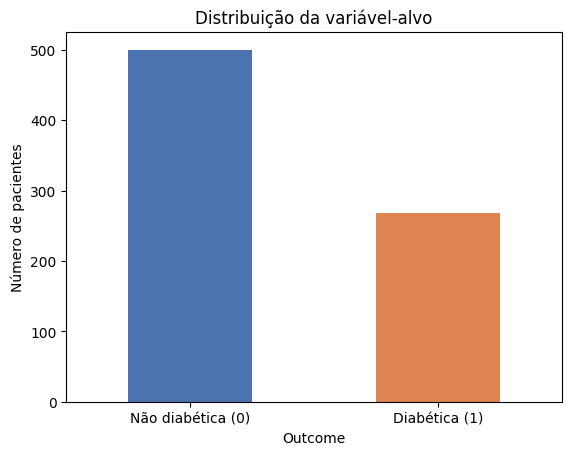

In [13]:
print("Distribuição da variável-alvo:")
print(dados["Outcome"].value_counts())
print()
print(dados["Outcome"].value_counts(normalize=True).round(3))

dados["Outcome"].value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452"])
plt.xticks([0, 1], ["Não diabética (0)", "Diabética (1)"], rotation=0)
plt.ylabel("Número de pacientes")
plt.title("Distribuição da variável-alvo")
plt.show()

As classes estão um pouco desbalanceadas: cerca de 65% das pacientes não desenvolveram diabetes, contra 35% que desenvolveram. Em bases desbalanceadas, a acurácia sozinha pode enganar (um modelo que sempre prevê a classe majoritária, já acertaria 65% das vezes sem aprender nada de útil). Vamos considerar essa informação na análise dos resultados.

### 3. Identificando e tratando valores ausentes

A primeira verificação que devemos fazer é checar diretamente por valores nulos (`NaN`):

In [14]:
print(dados.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


Nenhum valor nulo! À primeira vista, pareceria que os dados estão completos. Vamos olhar as estatísticas básicas de cada coluna:

In [15]:
dados.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


Repare no **mínimo** de algumas colunas: `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin` e `BMI` têm valor mínimo **zero**. Biologicamente, isso não faz sentido, pois nenhuma paciente viva tem pressão arterial, glicose ou IMC igual a zero. O que está acontecendo é que os valores ausentes desta base foram **codificados como zero**, em vez de como `NaN`. Um valor ausente disfarçado, que só aparece se investigarmos os dados com atenção, em vez de confiar cegamente em `isnull().sum()`.

In [16]:
colunas_com_zero_suspeito = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

print("Quantidade (e porcentagem) de zeros suspeitos em cada coluna:")
for coluna in colunas_com_zero_suspeito:
    n_zeros = (dados[coluna] == 0).sum()
    print(f"  {coluna:25s}: {n_zeros:4d} zeros  ({100 * n_zeros / len(dados):5.1f}%)")

Quantidade (e porcentagem) de zeros suspeitos em cada coluna:
  Glucose                  :    5 zeros  (  0.7%)
  BloodPressure            :   35 zeros  (  4.6%)
  SkinThickness            :  227 zeros  ( 29.6%)
  Insulin                  :  374 zeros  ( 48.7%)
  BMI                      :   11 zeros  (  1.4%)


A situação varia bastante entre as colunas: `Glucose` e `BMI` têm pouquíssimos zeros suspeitos (menos de 2%, plausivelmente só um pequeno erro de digitação ou instrumento), enquanto `Insulin` chega a quase **metade** dos registros (48,7%) e `SkinThickness` a quase 30%. Nesses dois casos, é bem mais provável que a medição simplesmente não tenha sido feita ou registrada para boa parte das pacientes.

O primeiro passo é **converter esses zeros disfarçados em `NaN`** de verdade, para que o pandas (e qualquer análise futura) os trate corretamente como ausentes, em vez de como um valor numérico válido que distorceria médias, desvios-padrão e o próprio modelo.

In [17]:
dados_nan = dados.copy()

for coluna in colunas_com_zero_suspeito:
    dados_nan[coluna] = dados_nan[coluna].replace(0, np.nan)

print("Valores ausentes por coluna, após a conversão:")
print(dados_nan.isnull().sum())

Valores ausentes por coluna, após a conversão:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


Com os valores ausentes agora devidamente identificados, precisamos decidir o que fazer com eles. As opções mais comuns são **remover** as linhas afetadas ou **imputar** (preencher) um valor plausível. Remover não seria a melhor opção: como `Insulin` teria quase metade das linhas descartadas, perderíamos informação demais.

Vamos imputar cada valor ausente pela **mediana da coluna**, calculada **separadamente para cada classe** (`Outcome`), em vez de uma única mediana global. A mediana é preferível à média aqui porque essas variáveis clínicas costumam ter distribuições assimétricas, com valores extremos que puxariam a média para longe do valor "típico". Nesse caso, usar a mediana **por classe** captura o fato de que pacientes diabéticas e não diabéticas tendem a ter valores tipicamente diferentes, então usar a mesma mediana para as duas classes jogaria fora essa informação.

**Um alerta metodológico importante**, antes de seguir: a imputação que faremos agora usa o conjunto de dados **inteiro** para calcular as medianas, o que é uma prática **aceitável para fins de exploração** (Seções 4 a 6, a seguir), mas **incorreta** se fosse usada diretamente para treinar e avaliar um modelo. Quando dividirmos os dados em treino e teste (Seção 7), a mediana "correta" a ser usada é apenas a do **conjunto de treino**, caso contrário, informação do conjunto de teste (que deveria simular dados nunca vistos) vazaria para dentro do pré-processamento, um problema chamado **vazamento de dados** (*data leakage*). Por isso, guardamos `dados_nan` (com os valores ausentes ainda não preenchidos) separadamente: vamos reutilizá-lo na Seção 7 para refazer essa imputação **do jeito certo**.

In [18]:
print("Mediana de cada coluna afetada, por classe (Outcome), calculada com TODOS os dados:")
print(dados_nan.groupby("Outcome")[colunas_com_zero_suspeito].median().round(1))

Mediana de cada coluna afetada, por classe (Outcome), calculada com TODOS os dados:
         Glucose  BloodPressure  SkinThickness  Insulin   BMI
Outcome                                                      
0          107.0           70.0           27.0    102.5  30.1
1          140.0           74.5           32.0    169.5  34.3


In [19]:
# dados_limpos: versão com imputação "global" (todos os dados), usada só para EXPLORAÇÃO
dados_limpos = dados_nan.copy()

# Para cada coluna que pode conter valores ausentes...
for coluna in colunas_com_zero_suspeito:
    # Calcula a mediana da coluna separadamente para cada classe
    # (0 = sem diabetes, 1 = com diabetes)
    medianas = dados_limpos.groupby("Outcome")[coluna].median()
    # Percorre cada classe (0 e 1)
    for classe in [0, 1]:
        # Seleciona apenas as linhas da classe atual com valores ausentes
        mascara = (dados_limpos["Outcome"] == classe) & (dados_limpos[coluna].isna())
        # Substitui os valores ausentes pela mediana da respectiva classe
        dados_limpos.loc[mascara, coluna] = medianas[classe]

print("Valores ausentes por coluna, após a imputação:")
print(dados_limpos.isnull().sum())
print()
print("Nenhum valor ausente restante:", dados_limpos.isnull().sum().sum() == 0)

Valores ausentes por coluna, após a imputação:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Nenhum valor ausente restante: True


**Uma ressalva importante**, para deixar claro que "tratar" valores ausentes nem sempre significa "resolver perfeitamente" o problema: com quase metade dos valores de `Insulin` sendo imputados, essa coluna passa a carregar bastante incerteza artificial, de modo que o valor "real" que a paciente tinha pode ser bem diferente da mediana usada. Uma alternativa razoável (não seguida aqui, para manter o notebook simples) seria descartar `Insulin` por completo, dado o volume de dados ausentes.

### 4. Calculando estatísticas descritivas

Com os dados já limpos, vamos revisitar as estatísticas descritivas, desta vez, sem a distorção dos zeros disfarçados:

In [20]:
dados_limpos.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,121.68,72.39,29.09,141.75,32.43,0.47,33.24,0.35
std,3.37,30.46,12.11,8.89,89.10,6.88,0.33,11.76,0.48
min,0.00,44.00,24.00,7.00,14.00,18.20,0.08,21.00,0.00
25%,1.00,99.75,64.00,25.00,102.50,27.50,0.24,24.00,0.00
50%,3.00,117.00,72.00,28.00,102.50,32.05,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,169.50,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


Mais interessante ainda é comparar as estatísticas **separadamente por classe**. Isso já começa a revelar quais atributos parecem estar associados ao desenvolvimento de diabetes.

In [21]:
estatisticas_por_classe = dados_limpos.groupby("Outcome").agg(["mean", "median", "std"]).round(2)
estatisticas_por_classe.T

Outcome                               0       1
Pregnancies              mean      3.30    4.87
                         median    2.00    4.00
                         std       3.02    3.74
Glucose                  mean    110.62  142.30
                         median  107.00  140.00
                         std      24.70   29.49
BloodPressure            mean     70.84   75.27
                         median   70.00   74.50
                         std      11.93   11.93
SkinThickness            mean     27.17   32.67
                         median   27.00   32.00
                         std       8.52    8.47
Insulin                  mean    117.17  187.62
                         median  102.50  169.50
                         std      75.69   94.11
BMI                      mean     30.85   35.40
                         median   30.10   34.30
                         std       6.50    6.59
DiabetesPedigreeFunction mean      0.43    0.55
                         median    0.34    0.45
                         std       0.30    0.37
Age                      mean     31.19   37.07
                         median   27.00   36.00
                         std      11.67   10.97

Já dá para notar diferenças claras entre os dois grupos em algumas colunas. Por exemplo, a glicose média tende a ser visivelmente mais alta entre as pacientes diabéticas. Vamos quantificar isso de forma mais direta, calculando a diferença percentual entre as médias dos dois grupos para cada atributo:

In [22]:
media_diabeticas = dados_limpos[dados_limpos["Outcome"] == 1].drop(columns="Outcome").mean()
media_nao_diabeticas = dados_limpos[dados_limpos["Outcome"] == 0].drop(columns="Outcome").mean()

diferenca_percentual = (100 * (media_diabeticas - media_nao_diabeticas) / media_nao_diabeticas).round(1)
diferenca_percentual.sort_values(ascending=False)

,0
Insulin,60.1
Pregnancies,47.5
Glucose,28.6
DiabetesPedigreeFunction,28.1
SkinThickness,20.2
Age,18.8
BMI,14.8
BloodPressure,6.3


Atributos como `Glucose`, `Insulin` e `Pregnancies` mostram diferenças percentuais grandes entre os dois grupos. Esses são bons candidatos a atributos informativos para o classificador que construiremos mais adiante. Atributos com diferença pequena (como `BloodPressure`) tendem a discriminar menos entre as classes.

### 5. Visualizando distribuições dos atributos

Vamos visualizar a distribuição de cada atributo com um histograma:

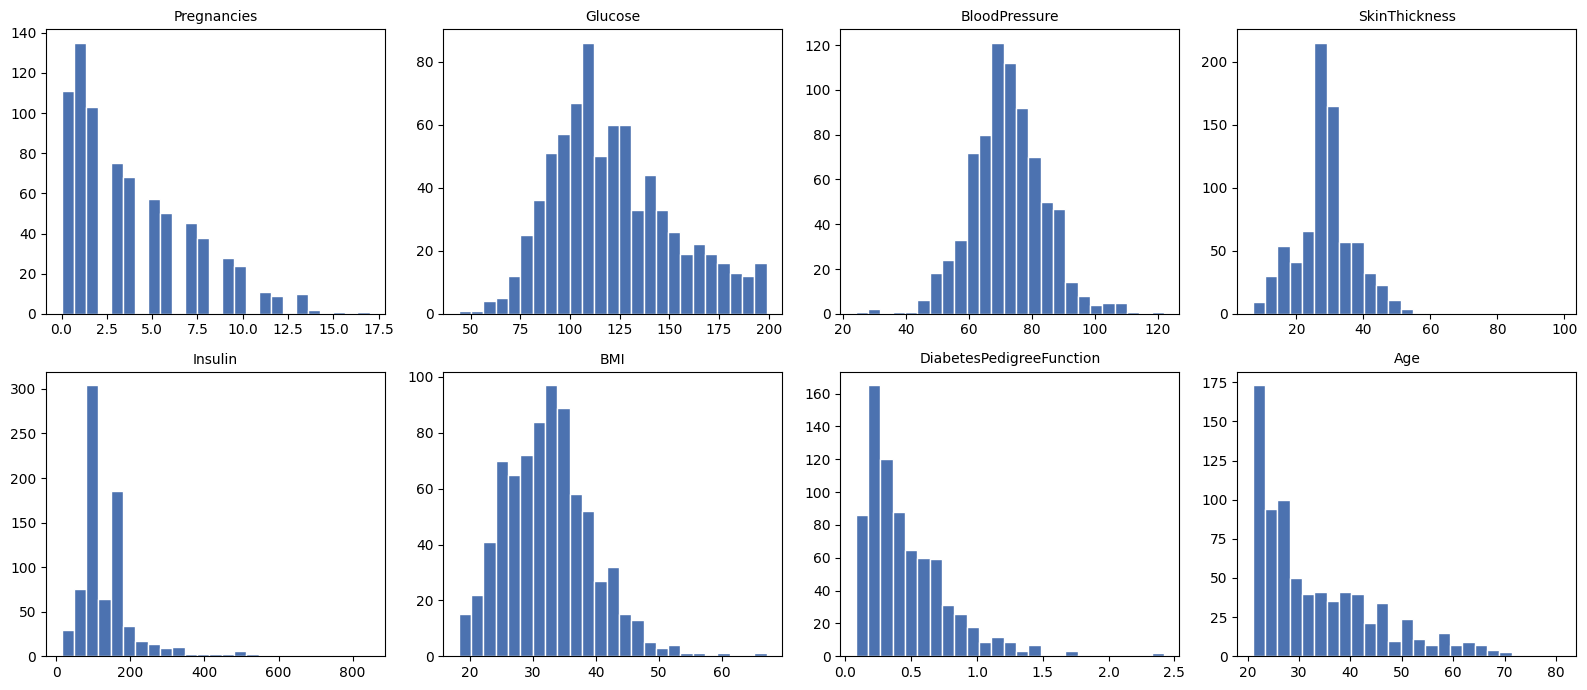

In [23]:
atributos = dados_limpos.drop(columns="Outcome").columns

fig, eixos = plt.subplots(2, 4, figsize=(16, 7))
eixos = eixos.ravel()

for i, atributo in enumerate(atributos):
    eixos[i].hist(dados_limpos[atributo], bins=25, color="#4C72B0", edgecolor="white")
    eixos[i].set_title(atributo, fontsize=10)

plt.tight_layout()
plt.show()

Algumas distribuições (`Age`, `DiabetesPedigreeFunction`, `Insulin`) são claramente **assimétricas à direita** (a maioria dos valores concentrada em uma faixa baixa, com uma cauda longa de valores altos). Isso confirma a escolha da mediana, em vez da média, para a imputação da Seção 3, já que a média seria influenciada por essa cauda.

Agora, o mais relevante para o problema de classificação: como cada atributo se distribui **separado por classe**. Usamos boxplots, que mostram mediana, quartis e possíveis valores atípicos (*outliers*) de forma compacta.

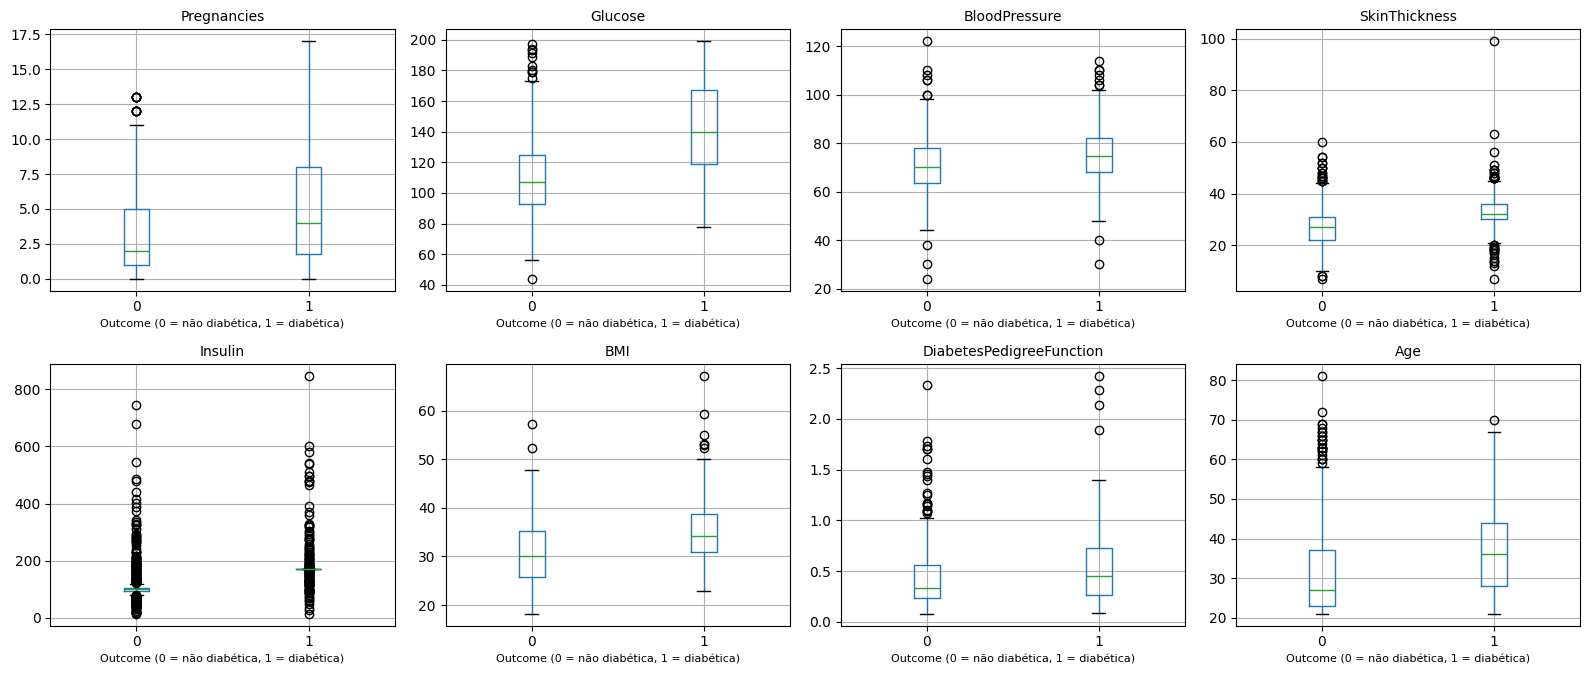

In [24]:
fig, eixos = plt.subplots(2, 4, figsize=(16, 7))
eixos = eixos.ravel()

for i, atributo in enumerate(atributos):
    dados_limpos.boxplot(column=atributo, by="Outcome", ax=eixos[i])
    eixos[i].set_title(atributo, fontsize=10)
    eixos[i].set_xlabel("Outcome (0 = não diabética, 1 = diabética)", fontsize=8)

plt.suptitle("")  # remove o título automático duplicado que o pandas adiciona
plt.tight_layout()
plt.show()

`Glucose` mostra a separação mais nítida entre as duas classes. As caixas praticamente não se sobrepõem, um forte indício de que este será um dos atributos mais úteis para o KNN. `BMI`, `Age` e `Pregnancies` também mostram alguma separação, ainda que menos marcante. Já `BloodPressure` e `SkinThickness` têm distribuições bem parecidas entre as duas classes. Esses são atributos que, sozinhos, discriminam pouco entre diabéticas e não diabéticas.

### 6. Analisando relações entre variáveis

Além de olhar cada atributo isoladamente, é importante entender como eles se relacionam entre si, tanto para identificar atributos redundantes (fortemente correlacionados um com o outro) quanto para ver quais se correlacionam mais com o próprio alvo `Outcome`.

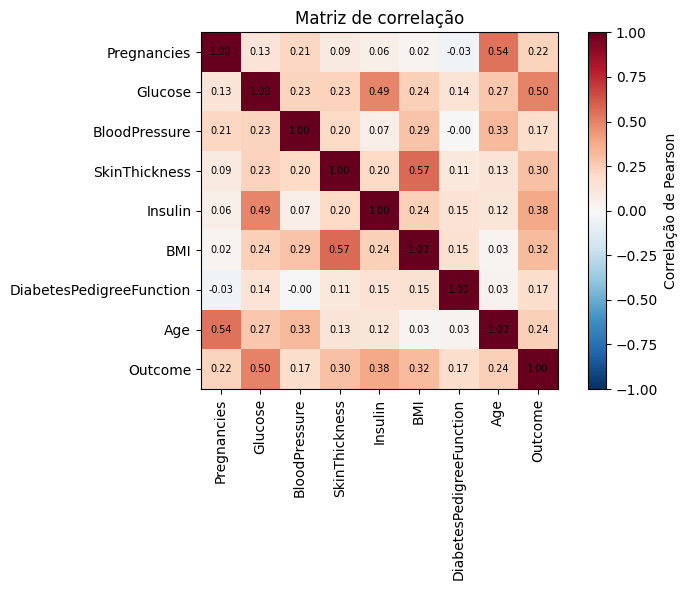

In [25]:
matriz_correlacao = dados_limpos.corr()

plt.figure(figsize=(8, 6))
plt.imshow(matriz_correlacao, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(label="Correlação de Pearson")
plt.xticks(range(len(matriz_correlacao)), matriz_correlacao.columns, rotation=90)
plt.yticks(range(len(matriz_correlacao)), matriz_correlacao.columns)

# Escreve o valor de cada correlação sobre o mapa de calor
for i in range(len(matriz_correlacao)):
    for j in range(len(matriz_correlacao)):
        plt.text(j, i, f"{matriz_correlacao.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)

plt.title("Matriz de correlação")
plt.tight_layout()
plt.show()

Duas leituras importantes desse mapa de calor:

- a **última linha/coluna** (`Outcome`) mostra a correlação de cada atributo com o alvo. `Glucose` se destaca com a correlação mais forte, seguida por `Insulin` e `BMI`, confirmando o que já havíamos observado nos boxplots da Seção 5;
- fora da linha/coluna do alvo, a correlação mais forte entre dois atributos aparece entre `SkinThickness` e `BMI`. Isso faz sentido fisiologicamente, já que ambos se relacionam com a quantidade de tecido adiposo do corpo. Nenhuma correlação entre atributos chega perto de 1.0, então não há um caso extremo de redundância que precisaríamos remover.

In [26]:
print("Correlação de cada atributo com o alvo (Outcome), em ordem decrescente:")
print(matriz_correlacao["Outcome"].drop("Outcome").sort_values(ascending=False).round(3))

Correlação de cada atributo com o alvo (Outcome), em ordem decrescente:
Glucose                     0.496
Insulin                     0.377
BMI                         0.316
SkinThickness               0.295
Age                         0.238
Pregnancies                 0.222
BloodPressure               0.174
DiabetesPedigreeFunction    0.174
Name: Outcome, dtype: float64


Vamos visualizar diretamente a relação entre os dois atributos mais associados ao alvo, colorindo cada ponto pela classe verdadeira. Esse é um bom jeito de "enxergar" antecipadamente o tipo de fronteira que um classificador como o KNN precisará aprender.

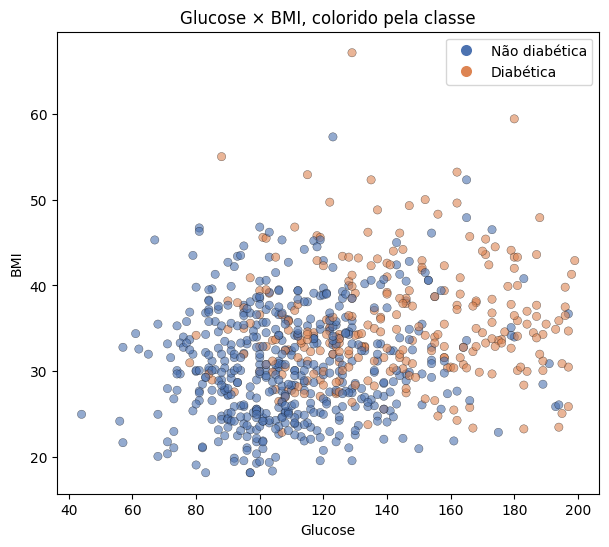

In [27]:
plt.figure(figsize=(7, 6))
cores = dados_limpos["Outcome"].map({0: "#4C72B0", 1: "#DD8452"})
plt.scatter(dados_limpos["Glucose"], dados_limpos["BMI"], c=cores, alpha=0.6, edgecolor="k", linewidth=0.3)

# Legenda manual (já que estamos usando scatter com cores mapeadas, não plt.legend automático)
from matplotlib.lines import Line2D
legenda = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#4C72B0", markersize=9, label="Não diabética"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#DD8452", markersize=9, label="Diabética"),
]
plt.legend(handles=legenda)

plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.title("Glucose × BMI, colorido pela classe")
plt.show()

Não existe uma separação perfeita (as cores se misturam bastante, especialmente na faixa intermediária de glicose), mas há uma tendência visível: pacientes com glicose mais alta aparecem com mais frequência entre as diabéticas (pontos laranja), especialmente à direita do gráfico. Essa sobreposição parcial é realista, pois problemas médicos raramente têm fronteiras perfeitamente nítidas, e é exatamente esse tipo de padrão, não linear e não perfeitamente separável, que o KNN é capaz de capturar.

### 7. Preparando os dados para aprendizado de máquina

Antes de treinar qualquer modelo, faltam alguns passos essenciais:

1. **separar os atributos (`X`) do alvo (`y`)**, e dividir em conjuntos de **treino** e **teste**: conjunto de teste fica reservado, usado só ao final, para avaliar o modelo em dados que ele nunca viu durante o treinamento;
2. **refazer a imputação de valores ausentes corretamente**: como alertamos na Seção 3, a versão `dados_limpos` foi imputada usando **todo** o conjunto de dados, o que vaza informação do teste para dentro do pré-processamento. Vamos corrigir isso agora;
3. **escalonar os atributos**: o KNN é um algoritmo baseado em **distância** e classifica um novo ponto observando seus vizinhos mais próximos no espaço dos atributos. Se os atributos estiverem em escalas muito diferentes (`Insulin` chega a centenas; `DiabetesPedigreeFunction` fica quase sempre abaixo de 2,5), a distância acaba dominada pelos atributos de maior magnitude numérica, independentemente de quão relevantes eles realmente sejam para prever a classe.

In [28]:
from sklearn.model_selection import train_test_split

X_bruto = dados_nan.drop(columns="Outcome")
y = dados_nan["Outcome"]
# separa em treinamento e teste
X_train_bruto, X_test_bruto, y_train, y_test = train_test_split(X_bruto, y, test_size=0.25, random_state=42, stratify=y)

print("Treinamento:", X_train_bruto.shape, " Teste:", X_test_bruto.shape)
print("Valores ausentes em X_train:", X_train_bruto.isnull().sum().sum())
print("Valores ausentes em X_test: ", X_test_bruto.isnull().sum().sum())

Treinamento: (576, 8)  Teste: (192, 8)
Valores ausentes em X_train: 475
Valores ausentes em X_test:  177


In [29]:
# Calcula as medianas de imputação usando APENAS o conjunto de treino
medianas_treino = X_train_bruto.join(y_train).groupby("Outcome")[colunas_com_zero_suspeito].median()

print("Medianas calculadas somente com o conjunto de treino:")
print(medianas_treino.round(1))

Medianas calculadas somente com o conjunto de treino:
         Glucose  BloodPressure  SkinThickness  Insulin   BMI
Outcome                                                      
0          108.0           70.0           27.0     95.0  30.5
1          142.0           74.5           32.5    168.0  34.4


In [30]:
def imputar_com_medianas_do_treino(X, y_correspondente, medianas):
    """Preenche valores ausentes em X usando as medianas (por classe) informadas --
    que devem ter sido calculadas usando apenas o conjunto de treino."""
    X_imputado = X.copy()
    for coluna in medianas.columns:
        for classe in medianas.index:
            mascara = (y_correspondente == classe) & (X_imputado[coluna].isna())
            X_imputado.loc[mascara, coluna] = medianas.loc[classe, coluna]
    return X_imputado


# Aplica as medianas do TREINO a ambos os conjuntos -- sem recalcular nada a partir do teste
X_train = imputar_com_medianas_do_treino(X_train_bruto, y_train, medianas_treino)
X_test = imputar_com_medianas_do_treino(X_test_bruto, y_test, medianas_treino)

print("Valores ausentes após a imputação correta -- treino:", X_train.isnull().sum().sum()," teste:", X_test.isnull().sum().sum())

Valores ausentes após a imputação correta -- treino: 0  teste: 0


Agora sim podemos escalonar os atributos, também aprendendo os parâmetros (média e desvio-padrão) apenas com o conjunto de treino:

In [31]:
from sklearn.preprocessing import StandardScaler

escalonador = StandardScaler().fit(X_train)
X_train_escalado = escalonador.transform(X_train)
X_test_escalado = escalonador.transform(X_test)

Usamos `stratify=y` na divisão treino/teste, pois isso garante que a proporção de diabéticas/não diabéticas fique aproximadamente a mesma nos dois conjuntos, evitando que uma divisão "por azar" concentre desproporcionalmente uma das classes no teste.

### 8. Treinando um classificador KNN

O **KNN** (*k-nearest neighbors*, k-vizinhos mais próximos) classifica um novo ponto observando as `k` observações mais próximas dele no conjunto de treino, e atribuindo a classe **majoritária** entre esses vizinhos. Vamos usar `k=5` (o padrão do scikit-learn), sem buscar um valor "ótimo" de `k`, já que isso seria uma forma de seleção de modelo, fora do escopo deste notebook.

In [32]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_escalado, y_train)

y_pred = knn.predict(X_test_escalado)

print("Previsões geradas para", len(y_pred), "pacientes do conjunto de teste.")

Previsões geradas para 192 pacientes do conjunto de teste.


Antes de seguir para a avaliação formal (Seção 9), vale um parênteses interessante. Treinamos o KNN acima **com** os dados escalonados, como manda a boa prática para métodos baseados em distância. Mas o que aconteceria se treinássemos o mesmo modelo **sem** escalonar? Vamos comparar diretamente:

In [33]:
from sklearn.metrics import accuracy_score

knn_sem_escalonar = KNeighborsClassifier(n_neighbors=5)
knn_sem_escalonar.fit(X_train, y_train)
y_pred_sem_escalonar = knn_sem_escalonar.predict(X_test)

acc_com = accuracy_score(y_test, y_pred)
acc_sem = accuracy_score(y_test, y_pred_sem_escalonar)

print(f"Acurácia COM escalonamento: {acc_com:.4f}")
print(f"Acurácia SEM escalonamento: {acc_sem:.4f}")

Acurácia COM escalonamento: 0.8281
Acurácia SEM escalonamento: 0.8542


Surpreendentemente, **não escalonar teve um desempenho um pouco melhor** neste conjunto de teste específico, que é o contrário do que a teoria costuma sugerir! Vale investigar por quê, em vez de apenas anotar o número: repare que `Glucose` é, ao mesmo tempo, o atributo com **maior desvio-padrão bruto** entre os originais e o **mais correlacionado com o alvo** (Seção 6). Sem escalonamento, `Glucose` acaba dominando o cálculo de distância do KNN e, neste caso particular, essa dominância **coincide** com o atributo que realmente importa mais para a classificação, em vez de atrapalhar.

Isso **não** é uma regra geral, e não deve ser lido como "escalonar não vale a pena". É uma coincidência específica deste conjunto de dados, em que o atributo de maior escala também é o mais relevante. Em geral, sem controlar isso explicitamente, corremos o risco oposto: um atributo pouco relevante, mas de escala grande, dominar a distância e **piorar** o modelo. A prática recomendada continua sendo escalonar por padrão; o que fizemos aqui foi verificar empiricamente, em vez de assumir cegamente, algo que vale a pena fazer sempre que for viável. Seguimos com a versão **escalonada** (`y_pred`) para a avaliação da próxima seção, por ser a prática mais robusta e a que generaliza melhor para outros conjuntos de dados.

### 9. Avaliação do modelo

Como vimos na Seção 2, as classes estão desbalanceadas (65% / 35%). Por isso, a **acurácia sozinha** pode dar uma impressão exageradamente boa do modelo (um classificador "preguiçoso", que sempre prevê "não diabética", já acertaria 65% das vezes sem aprender nada). Vamos complementar com métricas mais informativas, incluindo a **matriz de confusão**.

In [34]:
from sklearn.metrics import (accuracy_score, ConfusionMatrixDisplay)

acuracia = accuracy_score(y_test, y_pred)

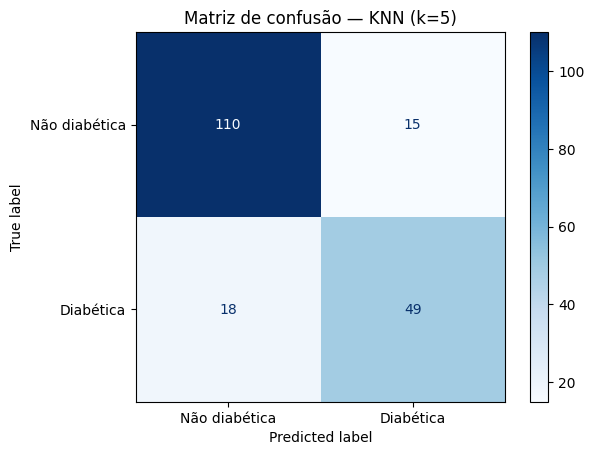

In [35]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Não diabética", "Diabética"], cmap="Blues"
)
plt.title("Matriz de confusão — KNN (k=5)")
plt.show()

A matriz de confusão deixa claro que o modelo tende a acertar mais a classe majoritária (não diabética) do que a minoritária (diabética), que é um padrão comum em bases desbalanceadas, mesmo sem nenhum desequilíbrio intencional no algoritmo. Em futuras aulas, vamos explorar métricas mais adequadas para tratar o desbalanceamento de dados.

### Conclusão

Neste notebook, percorremos o fluxo completo de um projeto simples de classificação, do dado bruto até um modelo avaliado:

1. **carregamos** o Pima Indians Diabetes Dataset em um `DataFrame`, definindo os nomes de coluna manualmente;
2. **exploramos a estrutura**: tipos de dado, duplicatas, e a distribuição (desbalanceada) do alvo;
3. **identificamos e tratamos valores ausentes** — o ponto mais sutil do notebook: zeros usados como codificação disfarçada de dado ausente em 5 colunas, com imputação pela mediana **por classe**;
4. **calculamos estatísticas descritivas**, comparando médias e medianas entre pacientes diabéticas e não diabéticas;
5. **visualizamos distribuições** com histogramas e boxplots, identificando `Glucose` como o atributo com a separação mais nítida entre classes;
6. **analisamos relações entre variáveis** com uma matriz de correlação e um gráfico de dispersão;
7. **preparamos os dados** com uma divisão treino/teste estratificada e escalonamento dos atributos;
8. **treinamos um KNN** simples, com `k=5` fixo, sem nenhuma busca de hiperparâmetro;
9. **avaliamos** com acurácia, precisão, recall, F1-score e matriz de confusão — discutindo por que a acurácia sozinha pode enganar em bases desbalanceadas.

### Exercícios de fixação

1. Repita a Seção 3 usando a **média** em vez da **mediana** para a imputação. Os resultados da Seção 9 mudam de forma perceptível?

2. Na Seção 3, em vez de imputar `Insulin`, remova essa coluna inteira (dado o alto percentual de valores ausentes) e refaça as Seções 7 a 9. O desempenho do modelo piora, melhora, ou fica aproximadamente o mesmo?

3. Volte à Seção 8 e treine o KNN com alguns valores diferentes de `k` (por exemplo, 1, 3, 5, 10, 15, 20). Os resultados mudam?